# Data generator sanity check

Generate a dataset from each generator module in `data_generator_funs` (linear, polynomial [quadratic/cubic], exponential), then visualize:
- the X/Y correlation structure, with the generator's "sensitive" params outlined
- a sparsity + nonlinearity summary per output (the "how sparse / how nonlinear" view)
- a few scatterplots of the actual Y vs. X shape

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from itertools import permutations

sys.path.append(str(Path.cwd().parent))

from data_generator_funs.dataset import (
    generate_linear_dataset,
    generate_polynomial_dataset,
    generate_exponential_dataset,
    save_dataset_netcdf,
    default_nc_filename,
)
from utils.plotting import plot_correlation, plot_data_overview, plot_scatter_examples

import xarray as xr
from pathlib import Path

In [3]:
from data_generator_funs.dataset import load_linear_dataset

In [2]:
import pandas as pd

In [3]:
rng = np.random.default_rng()
rng.choice(10, size=5, replace=False)

array([9, 2, 7, 6, 8])

In [14]:
from data_generator_funs.dataset import generate_linear_dataset

lin_full = generate_linear_dataset(
    n_samples=500, n_params=15, n_outputs=20,
    structure="full",
    structure_kwargs=dict(n_sensitive_para=2, n_sensitive_output=5, sensitivity_multiplier=3.0),
    noise_std=0.0, structural_idx=[], structural_error_level=0.0,
    seed=1,
    nc_path="/glade/work/qingyuany/cliffnotes",
)

In [15]:
lin_diag = generate_linear_dataset(
    n_samples=500, n_params=15, n_outputs=20,
    structure="diag", 
    structure_kwargs=dict(n_sensitive_para=2, window_size = 3, sensitivity_multiplier = 3.0),
    noise_std=0.0,
    structural_idx=[],
    structural_error_level=0.0,
    nc_path = '/glade/work/qingyuany/cliffnotes/',
    seed=1
)

In [16]:
lin_tri = generate_linear_dataset(
    n_samples=500, n_params=15, n_outputs=20,
    structure="triu", 
    structure_kwargs = dict(n_sensitive_para = 2, n_sensitive_outputs = 5),
    noise_std=0.0,
    structural_idx=[],
    structural_error_level=0.0,
    nc_path = '/glade/work/qingyuany/cliffnotes/',
    seed=1
)

In [39]:
overlap_ds = generate_linear_dataset(
    n_samples=300, n_params=10, n_outputs=20,
    structure="overlapping_blocks",
    structure_kwargs=dict(
        param_groups=[[0, 1, 2], [1, 2], list(range(3,10))],       # x1,x2 -> group 0 ; x2,x3 -> group 1 (x2 shared)
        output_group_sizes=[4, 6, 10],            # group 0 -> y1-y4 ; group 1 -> y5-y10
        sensitivity_multiplier=3.0,
        background_scale=0.0,      # exact zero off-block -> rows 3-9, cols 0-9 stay empty
        extra_links=[(0, -1)],     # group 0's params (rows 0-2) also get real coefficients in the last group's columns (10-19)
        shared_scale=0.5,
    ),
    seed=1,
    nc_path = '/glade/work/qingyuany/cliffnotes/'
)

In [ ]:
ds1 = load_linear_dataset("/glade/work/qingyuany/cliffnotes/linear_full_n500_p15_o20_nsp2_nso5_sm3")
ds2 = load_linear_dataset("/glade/work/qingyuany/cliffnotes/linear_diag_n500_p15_o20_nsp2_ws3_sm3")
ds3 = load_linear_dataset("/glade/work/qingyuany/cliffnotes/linear_triu_n500_p15_o20_nsp2_nso5")
ds4 = load_linear_dataset("/glade/work/qingyuany/cliffnotes/linear_overlapping_blocks_n300_p10_o20_pg0-1-2-1-2-3-4-5-6-7-8-9_ogs4-6-10_sm3_bs0_el0-m1_ss0p5")

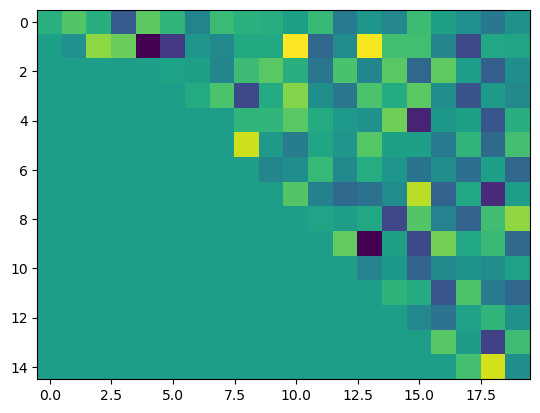

In [6]:
plt.imshow(ds3['coefficients'])

In [12]:
ds4['x_true']

array([-0.76946599,  0.75719482, -0.40132223,  0.49185823,  0.87473267,
       -0.29020051,  0.86271288,  0.76445013, -0.75676444, -0.74433614])

In [47]:
(ds4["x_true"] @ ds4['coefficients'] - ds4["y_true"])

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0.])

In [29]:
ds = load_linear_dataset("/glade/work/qingyuany/cliffnotes/linear_full_n400_p10_o5_nsp2_nso5_sm3")

In [3]:
n_sample = [100, 200, 400, 800]
n_paras = [10, 20, 40, 80]
n_outputs = [10, 40, 80, 120, 240]
n_sensitive_para = [0, 1, 2 , 3, 4]
n_sensitive_output = [0, 2, 4 , 6]
sensitivity_multiplier = [1.0, 2.0]
window_sizes = [2, 3, 4]

In [30]:
lin = generate_linear_dataset(
    n_samples=300, n_params=20, n_outputs=10,
    structure="full",
    structure_kwargs=dict(n_sensitive_para=3, n_sensitive_output=3, sensitivity_multiplier=3.0),
    noise_std=0.0,
    structural_idx=[0], structural_error_level=0.0,
    seed=1,
    nc_path='/glade/work/qingyuany/cliffnotes/'
)

In [31]:
X = pd.read_csv('/glade/work/qingyuany/cliffnotes/linear_full_n300_p20_o10_nsp3_nso3_sm3/X.csv')
Y = pd.read_csv('/glade/work/qingyuany/cliffnotes/linear_full_n300_p20_o10_nsp3_nso3_sm3/X.csv')
nc = xr.open_dataset('/glade/work/qingyuany/cliffnotes/linear_full_n300_p20_o10_nsp3_nso3_sm3/linear_full_n300_p20_o10_nsp3_nso3_sm3.nc')
x_true = pd.read_csv('/glade/work/qingyuany/cliffnotes/linear_full_n300_p20_o10_nsp3_nso3_sm3/x_true.csv')
y_true = pd.read_csv('/glade/work/qingyuany/cliffnotes/linear_full_n300_p20_o10_nsp3_nso3_sm3/y_true.csv')

In [32]:
A = nc['coefficients']

In [36]:
X @ A 

,0,1,2,3,4,5,6,7,8,9
0,-3.936906,-2.737742,1.756439,-5.590468,-3.303054,2.284148,0.832794,0.307597,-0.568461,4.865588
1,7.465315,11.791805,0.095590,6.418473,0.003414,-2.633754,-4.889766,-3.862994,4.544544,-13.632425
2,-2.920341,1.992949,-0.351772,-3.386706,2.986312,-3.422154,3.941935,2.220945,3.271434,-2.579521
3,-5.141944,2.744036,0.999565,-1.095507,1.667539,2.085288,-0.319087,-0.190638,-0.972796,-2.829572
4,-12.014165,7.959935,2.982557,-8.623867,6.435087,-0.781013,3.486708,1.057828,8.806303,-2.453776
...,...,...,...,...,...,...,...,...,...,...
295,1.438544,9.290795,-3.180444,-2.619265,4.400401,-2.394293,0.861156,1.313386,-3.613361,-9.975760
296,8.640373,-6.771078,-1.180785,-5.120248,0.411001,2.773285,4.821851,2.927774,-2.072830,3.476757
297,-4.826549,2.804508,-3.635401,-3.742023,2.049262,-3.473317,-2.324096,-3.050885,3.392928,0.503565
298,0.028685,5.255632,2.919135,-2.705801,-4.610030,4.396149,5.008360,-2.968697,2.155029,-9.588821


In [37]:
Y

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,x14,x15,x16,x17,x18,x19
0,0.345584,0.821618,0.330437,-1.303157,0.905356,0.446375,-0.536953,0.581118,0.364572,0.294132,0.028422,0.546713,-0.736454,-0.162910,-0.482119,0.598846,0.039722,-0.292457,-0.781908,-0.257192
1,0.008142,-0.275603,1.294064,1.006724,-2.711162,-1.889013,-0.174772,-0.422190,0.213643,0.217322,2.117839,-1.112021,-0.377605,2.042772,0.646703,0.663063,-0.514006,-1.648075,0.167465,0.109014
2,-1.227352,-0.683227,-0.072044,-0.944752,-0.098270,0.095483,0.035586,-0.506292,0.593748,0.891167,0.320848,-0.818230,0.731652,-0.501440,0.879161,-1.071787,0.914467,-0.020063,-1.248749,-0.313899
3,0.054102,0.272791,-0.982188,-1.107373,0.199585,-0.466750,0.235506,0.759520,-1.648787,0.254388,1.224647,-0.297527,-0.810815,0.752244,0.253447,0.895883,-0.345216,-1.481818,-0.110011,-0.445828
4,0.775324,0.193633,-1.630849,-1.195163,0.883789,0.679765,-0.640243,-0.001049,0.445574,0.468404,0.876242,0.256486,-0.094828,-0.258848,1.055743,-2.250854,-0.138655,0.033000,-1.425349,0.332814
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,-0.354177,0.528020,-0.455281,-0.194545,-0.970259,0.113772,-0.174342,-0.894651,0.476043,0.982936,0.440564,-1.165387,0.229629,0.735979,1.065009,1.153046,0.896062,-0.211605,0.476391,0.658786
296,0.084321,0.295033,-1.038004,0.271011,-0.463282,-0.173760,1.655362,0.194790,0.279632,-0.645265,-1.489061,-1.217441,-0.357293,-0.252661,-1.802538,-0.689574,-0.028045,-0.834413,-0.402493,0.084167
297,1.169274,0.300668,1.465654,-1.389013,1.240850,-0.204109,0.947227,1.928846,0.910990,0.392271,1.546987,-0.497026,1.003359,0.362022,0.358219,-0.613085,0.310460,0.341823,-0.035625,0.310596
298,-1.382769,0.907121,-0.262837,0.225114,-0.637697,-0.360081,-0.650103,1.219092,-0.828168,-0.752300,-0.188939,-1.214012,-1.022116,0.188219,0.267555,0.724192,0.421144,-0.873405,-1.043968,0.996497


## Linear dataset

`y_k = sum_i b[i,k] * x_i`, with a few (param, output) pairs marked "sensitive" (amplified coefficients), 20% observational noise, and structural error injected on output 0.

In [18]:
count_ds = 0
for n_s_p in n_sensitive_para:
    for n_s_o in n_sensitive_output:
        for s_m in sensitivity_multiplier:
            for n_s in n_sample:
                for n_p in n_paras:
                    for n_o in n_outputs:
                        lin_full = generate_linear_dataset(
                            n_samples=n_s, n_params=n_o, n_outputs=n_p,
                            structure="full", 
                            structure_kwargs=dict(n_sensitive_para=n_s_p, n_sensitive_output= n_s_o, sensitivity_multiplier=s_m),
                            noise_std=0.0,
                            structural_idx=[],
                            structural_error_level=0.0,
                            nc_path = '/glade/work/qingyuany/cliffnotes/',
                            seed=1
                        )
                        count_ds = 1 + count_ds

In [22]:
3200 * 3/4 + 3200

5600.0

In [19]:
for n_s_p in n_sensitive_para:
    for w_s in window_sizes:
        for s_m in sensitivity_multiplier:
            for n_s in n_sample:
                for n_p in n_paras:
                    for n_o in n_outputs:
                        lin_diag = generate_linear_dataset(
                            n_samples=n_s, n_params=n_p, n_outputs=n_o,
                            structure="diag", 
                            structure_kwargs=dict(n_sensitive_para=n_s_p, window_size = w_s, sensitivity_multiplier = s_m),
                            noise_std=0.0,
                            structural_idx=[],
                            structural_error_level=0.0,
                            nc_path = '/glade/work/qingyuany/cliffnotes/',
                            seed=1
)

In [21]:
for n_s_o in n_sensitive_output:
    for n_s_p in n_sensitive_para:
        for n_s in n_sample:
            for n_p in n_paras:
                for n_o in n_outputs:
                    lin_tri = generate_linear_dataset(
                        n_samples=n_s, n_params=n_p, n_outputs=n_o,
                        structure="triu", 
                        structure_kwargs = dict(n_sensitive_para = n_s_p, n_sensitive_outputs = n_s_o),
                        noise_std=0.0,
                        structural_idx=[],
                        structural_error_level=0.0,
                        nc_path = '/glade/work/qingyuany/cliffnotes/',
                        seed=1
                    )

In [29]:
file_full = sorted(Path('/glade/work/qingyuany/cliffnotes/').glob('*full*.nc'))
file_diag = sorted(Path('/glade/work/qingyuany/cliffnotes/').glob('*diag*.nc'))
file_tri = sorted(Path('/glade/work/qingyuany/cliffnotes/').glob('*tri*.nc'))


In [40]:
ds = xr.open_dataset(file_full[1600])
file_full[1600]


PosixPath('/glade/work/qingyuany/cliffnotes/linear_full_n400_p10_o10_nsp0_nso0_sm1.nc')

In [42]:
ds

<xarray.Dataset> Size: 65kB
Dimensions:          (sample: 400, input_feature: 10, output_feature: 10,
                      paras_to_vary_index: 0, outputs_to_vary_index: 0)
Dimensions without coordinates: sample, input_feature, output_feature,
                                paras_to_vary_index, outputs_to_vary_index
Data variables:
    X                (sample, input_feature) float64 32kB ...
    Y                (sample, output_feature) float64 32kB ...
    x_true           (output_feature) float64 80B ...
    y_true           (output_feature) float64 80B ...
    coefficients     (input_feature, output_feature) float64 800B ...
    paras_to_vary    (paras_to_vary_index) int64 0B ...
    outputs_to_vary  (outputs_to_vary_index) int64 0B ...
    structural_bias  (output_feature) float64 80B ...
Attributes:
    summary:                 Synthetic parameter-estimation dataset generated...
    model:                   linear
    structure:               full
    n_samples:               400
    n_params:                10
    n_outputs:               10
    noise_std:               0.0
    structural_idx:          []
    structural_error_level:  0.0
    seed:                    1
    metadata_json:           {"model": "linear", "structure": "full", "n_samp...

In [48]:
(ds['X'].values @ ds['coefficients'].values - ds['Y']).max() - (ds['X'].values @ ds['coefficients'].values - ds['Y']).min()

<xarray.DataArray 'Y' ()> Size: 8B
array(0.)

In [49]:
(ds['x_true'].values @ ds['coefficients'].values - ds['y_true'])

<xarray.DataArray 'y_true' (output_feature: 10)> Size: 80B
array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
Dimensions without coordinates: output_feature
Attributes:
    description:  The generating process applied to x_true, with observation ...